This notebook computes the heterogeneous demand proxy Dᵢ for each London LSOA. It reads from the two cleaned CSVs already produced by 02_data_cleaning.ipynb. The NTS-derived behavioural parameters (Pd and Ppub) are set as constants here based on NTS 2024 aggregate statistics — they do not vary by LSOA

Pd (daily charging probability): NTS 2024 indicates that private cars in the UK travel an average of around 20 miles per day, whilst EVs have an average range of around 200 miles; therefore, they need to be charged approximately every 10 days, so Pd = 0.1
Ppub (proportion dependent on public charging): NTS 2024 indicates that approximately 40% of EV owners do not have access to private charging facilities; Ppub = 0.4
α (equity adjustment factor): to weight demand in deprived areas; set to 0.3

In [2]:
import os
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import warnings
warnings.filterwarnings("ignore")

# Project root
BASE = "/Users/alexia/Documents/CASA/Dissertation"

# Output folder
FIG_DIR = os.path.join(BASE, "06_outputs", "figures")
os.makedirs(FIG_DIR, exist_ok=True)

# Input files — both already produced by 02_data_cleaning.ipynb
CENSUS_CSV = os.path.join(BASE, "05_processed", "census_london_clean.csv")
IMD_CSV    = os.path.join(BASE, "05_processed", "imd_london_clean.csv")
LSOA_SHP   = os.path.join(BASE, "03_data", "demand", "spatial", "LSOA_2021_EW_BGC_V5.shp")

# NTS 2024 behavioural parameters — applied uniformly across all LSOAs
Pd   = 0.1   # daily probability of needing to charge
Ppub = 0.4   # proportion of EV drivers relying on public charging
alpha = 0.3  # equity adjustment weight for deprived areas

# Load data
census = pd.read_csv(CENSUS_CSV)
imd    = pd.read_csv(IMD_CSV)
lsoa_gdf = gpd.read_file(LSOA_SHP).to_crs(epsg=27700)

# Standardise LSOA code column name
if "LSOA21CD" in lsoa_gdf.columns:
    lsoa_gdf = lsoa_gdf.rename(columns={"LSOA21CD": "lsoa_code"})

print("census shape :", census.shape)
print("imd shape    :", imd.shape)
print("lsoa_gdf CRS :", lsoa_gdf.crs)
print()
print("NTS parameters — Pd:", Pd, "| Ppub:", Ppub, "| alpha:", alpha)

census shape : (4994, 10)
imd shape    : (4994, 6)
lsoa_gdf CRS : EPSG:27700

NTS parameters — Pd: 0.1 | Ppub: 0.4 | alpha: 0.3


### Merge Data & Compute Dᵢ

This cell merges census and IMD onto a single DataFrame, normalises IMD rank to [0, 1] (higher = more deprived), then applies the demand formula. The result is one row per LSOA with its computed demand value Dᵢ. We also normalise Dᵢ itself at the end so it can be used directly as a weight in the location-allocation model later

In [3]:
# Merge census and IMD on lsoa_code
df = census.merge(
    imd[["lsoa_code", "lad_name", "imd_rank", "imd_decile", "imd_imputed"]],
    on="lsoa_code",
    how="inner"
)
print("Merged shape:", df.shape)

# Normalise imd_rank to [0, 1]
# imd_rank: lower value = more deprived, so invert so that higher normalised value = more deprived
rank_min = df["imd_rank"].min()
rank_max = df["imd_rank"].max()
df["imd_norm"] = (rank_max - df["imd_rank"]) / (rank_max - rank_min)

# Verify direction: most deprived LSOA should have imd_norm close to 1
print("imd_norm range:", df["imd_norm"].min().round(4), "–", df["imd_norm"].max().round(4))
print("Most deprived row (imd_norm max):")
print(df.loc[df["imd_norm"].idxmax(), ["lsoa_code", "lsoa_name", "imd_rank", "imd_norm"]])

# Compute demand Dᵢ using the formula:
# Dᵢ = Pᵢ × Cᵢ × Pd × Ppub × (1 + α × IMDᵢ_norm)
# Pᵢ = total_residents (TS001)
# Cᵢ = car_ownership_rate (TS045)
# Pd, Ppub, alpha = NTS-derived constants set in Section 0
df["demand"] = (
    df["total_residents"]
    * df["car_ownership_rate"]
    * Pd
    * Ppub
    * (1 + alpha * df["imd_norm"])
)

# Normalise demand to [0, 1] for use as weights in the location-allocation model
demand_min = df["demand"].min()
demand_max = df["demand"].max()
df["demand_norm"] = (df["demand"] - demand_min) / (demand_max - demand_min)

# Summary statistics
print()
print("Demand Dᵢ summary:")
print(df["demand"].describe().round(3))
print()
print("Sample output:")
print(df[["lsoa_code", "lsoa_name", "total_residents", "car_ownership_rate",
          "imd_norm", "demand", "demand_norm"]].head(5).to_string())

Merged shape: (4994, 14)
imd_norm range: 0.0 – 1.0
Most deprived row (imd_norm max):
lsoa_code        E01002082
lsoa_name    Haringey 013A
imd_rank               546
imd_norm               1.0
Name: 2082, dtype: object

Demand Dᵢ summary:
count    4994.000
mean       48.157
std        15.970
min         5.737
25%        36.396
50%        49.974
75%        59.221
max       115.838
Name: demand, dtype: float64

Sample output:
   lsoa_code            lsoa_name  total_residents  car_ownership_rate  imd_norm     demand  demand_norm
0  E01000001  City of London 001A             1475              0.3369  0.105069  20.503641     0.134115
1  E01000002  City of London 001B             1384              0.2985  0.068214  16.863129     0.101049
2  E01000003  City of London 001C             1613              0.1878  0.551207  14.120525     0.076139
3  E01000005  City of London 001E             1100              0.2171  0.746010  11.690256     0.054066
4  E01032739  City of London 001F             1

## Save Results & Plot Dᵢ Distribution

 Save the demand table to 05_processed/ for use in later notebooks, then produce two plots: a choropleth map of Dᵢ at LSOA level, and a histogram showing the distribution of demand values across all LSOAs. The choropleth is one of the key output figures

In [4]:
# Save demand table to 05_processed/
output_path = os.path.join(BASE, "05_processed", "demand_london.csv")
df.to_csv(output_path, index=False)
print("Saved to:", output_path)
print("Columns:", df.columns.tolist())

# Merge demand onto LSOA boundary for mapping
lsoa_demand = lsoa_gdf.merge(
    df[["lsoa_code", "demand", "demand_norm", "imd_norm", "imd_decile"]],
    on="lsoa_code",
    how="left"
)

# Filter to London only
london_demand = lsoa_demand[lsoa_demand["demand"].notna()].copy()
print("London LSOAs with demand:", len(london_demand))

Saved to: /Users/alexia/Documents/CASA/Dissertation/05_processed/demand_london.csv
Columns: ['lsoa_code', 'lsoa_name', 'total_residents', 'cars_0', 'cars_1', 'cars_2', 'cars_3plus', 'total_households', 'total_cars', 'car_ownership_rate', 'lad_name', 'imd_rank', 'imd_decile', 'imd_imputed', 'imd_norm', 'demand', 'demand_norm']
London LSOAs with demand: 4994


## Choropleth Map of Dᵢ

 The choropleth shows spatial heterogeneity in demand — this is the visual proof that your demand estimation is not uniform across LSOAs, directly addressing the "heterogeneous demand" requirement. Darker colour = higher demand. Areas with high population, moderate car ownership, and high deprivation (which boosts the equity term) show the highest Dᵢ values

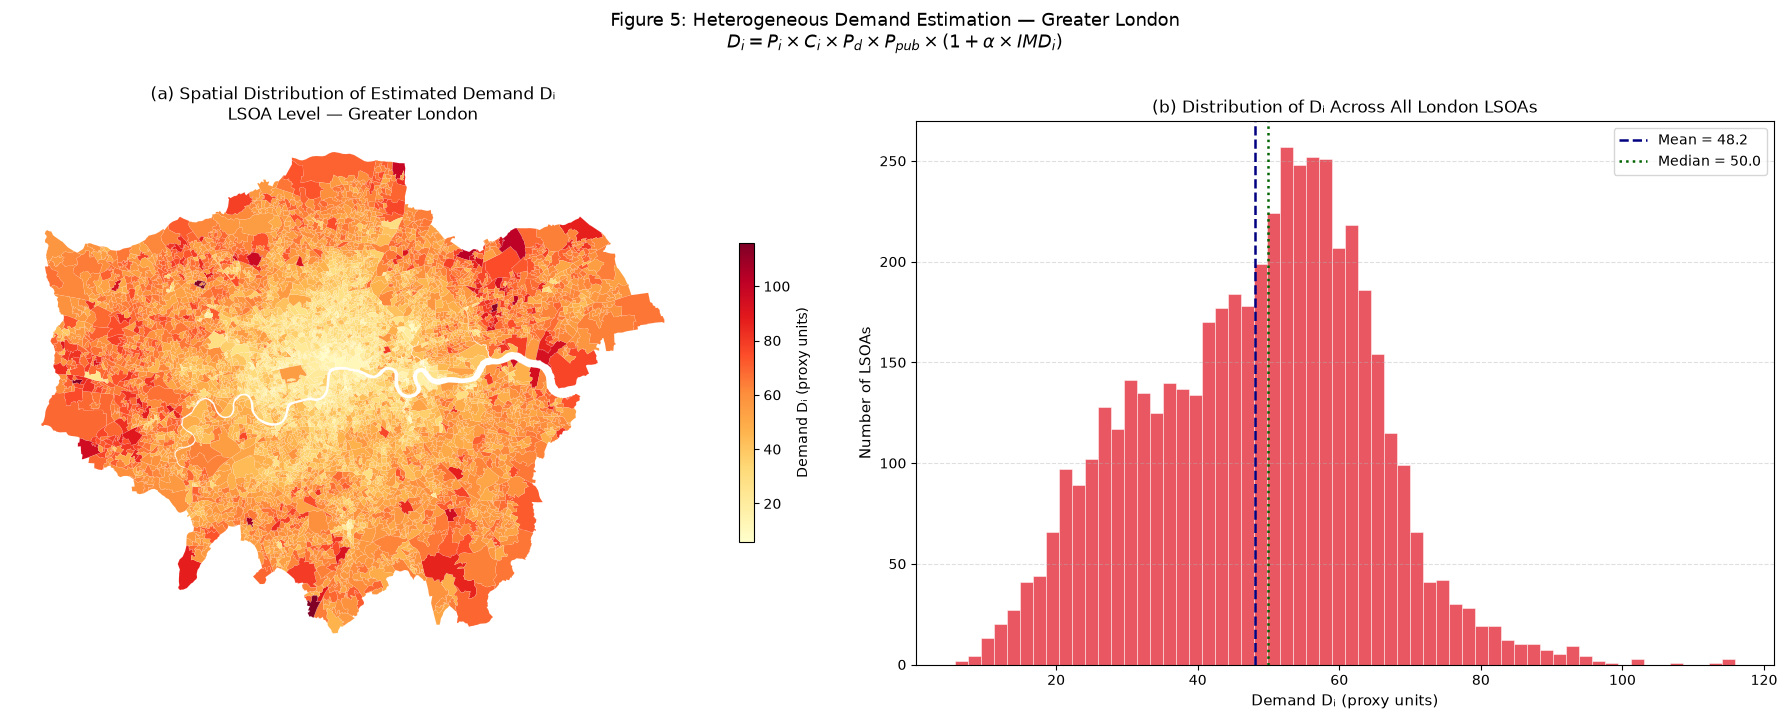

Saved: fig5_demand_distribution.png


In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Left: choropleth of raw demand Dᵢ
london_demand.plot(
    column="demand",
    ax=ax1,
    cmap="YlOrRd",
    legend=True,
    legend_kwds={
        "label": "Demand Dᵢ (proxy units)",
        "shrink": 0.55,
        "orientation": "vertical"
    },
    linewidth=0.05,
    edgecolor="white"
)
ax1.set_title("(a) Spatial Distribution of Estimated Demand Dᵢ\nLSOA Level — Greater London", fontsize=12)
ax1.axis("off")

# Right: histogram of demand values
ax2.hist(
    london_demand["demand"],
    bins=60,
    color="#e63946",
    edgecolor="white",
    linewidth=0.4,
    alpha=0.85
)
ax2.axvline(
    london_demand["demand"].mean(),
    color="navy", linewidth=1.8, linestyle="--",
    label=f"Mean = {london_demand['demand'].mean():.1f}"
)
ax2.axvline(
    london_demand["demand"].median(),
    color="darkgreen", linewidth=1.8, linestyle=":",
    label=f"Median = {london_demand['demand'].median():.1f}"
)
ax2.set_xlabel("Demand Dᵢ (proxy units)", fontsize=11)
ax2.set_ylabel("Number of LSOAs", fontsize=11)
ax2.set_title("(b) Distribution of Dᵢ Across All London LSOAs", fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(axis="y", linestyle="--", alpha=0.4)

fig.suptitle(
    "Figure 5: Heterogeneous Demand Estimation — Greater London\n"
    r"$D_i = P_i \times C_i \times P_d \times P_{pub} \times (1 + \alpha \times IMD_i)$",
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "fig5_demand_distribution.png"), dpi=200, bbox_inches="tight")
plt.show()
print("Saved: fig5_demand_distribution.png")